# H7: Multi-SNP Screen Across Vessel Density Metrics

**Rationale:** The existing analyses (H1–H6) focus on a single SNP (rs3184504/SH2B3). Groups.xlsx contains genotype data for ~60+ additional SNPs. This notebook screens all testable SNPs for associations with vessel density metrics.

**Expanded cohort:** Includes 3 additional CODEX samples (HBMP006, HBMP007, HDL098) from `ForSH2B3.csv`, bringing the total to 15 samples (10 Phenocycler + 5 CODEX).

**Platform sensitivity analysis:** Because CODEX and Phenocycler samples differ in tissue size and image quality, every test is run three ways:
1. **All samples** (n=15) — maximum power
2. **Phenocycler-only** (n=10) — unconfounded by platform
3. **Concordance check** — only trust results that survive both

> **Caveat:** With n=10–15 per analysis, power is limited. This is an exploratory screen to prioritize SNPs for future study.

In [1]:
import sys
sys.path.insert(0, '.')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu

from data_utils import (
    load_all_data, compute_density, extract_sample_id,
    GROUPS_XLSX, MAIN_REGIONS, EXCLUDE_SAMPLES,
    CODEX_SAMPLES, PHENOCYCLER_SAMPLES,
    _ALT_TO_HANDEL, setup_style, save_figure, save_table,
)

def benjamini_hochberg(pvals):
    """Benjamini-Hochberg FDR correction. Returns array of q-values."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    if n == 0:
        return pvals
    order = np.argsort(pvals)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, n + 1)
    qvals = pvals * n / ranks
    qvals_sorted = qvals[order]
    for i in range(n - 2, -1, -1):
        qvals_sorted[i + 1] = min(qvals_sorted[i + 1], 1.0)
        qvals_sorted[i] = min(qvals_sorted[i], qvals_sorted[i + 1])
    qvals_sorted[0] = min(qvals_sorted[0], 1.0)
    qvals = qvals_sorted[np.argsort(order)]
    return qvals

setup_style()

In [2]:
# --- Load merged data (Phenocycler + CODEX) ---
df = load_all_data()
density = compute_density(df)
project_samples = set(density['Sample'].unique())

print(f"Total samples: {len(project_samples)}")
print(f"\nBy platform:")
for plat in ['Phenocycler', 'CODEX']:
    samps = sorted(s for s in project_samples
                   if s in (PHENOCYCLER_SAMPLES if plat == 'Phenocycler' else CODEX_SAMPLES))
    print(f"  {plat} ({len(samps)}): {samps}")

# Tag density with platform
density['Platform'] = density['Sample'].apply(
    lambda s: 'CODEX' if s in CODEX_SAMPLES else 'Phenocycler'
)

print(f"\nGenotypes (all):")
geno_counts = density.drop_duplicates('Sample').groupby('Genotype', observed=True)['Sample'].apply(sorted)
for g, samps in geno_counts.items():
    print(f"  {g} ({len(samps)}): {samps}")

Total samples: 15

By platform:
  Phenocycler (10): ['HDL011', 'HDL018', 'HDL021', 'HDL043', 'HDL052', 'HDL053', 'HDL055', 'HDL063', 'HDL070', 'HDL086']
  CODEX (5): ['1901HBMP004', 'HBMP006', 'HBMP007', 'HDL073', 'HDL098']

Genotypes (all):
  C/C (4): ['HDL011', 'HDL053', 'HDL055', 'HDL098']
  C/T (8): ['HBMP006', 'HBMP007', 'HDL018', 'HDL021', 'HDL043', 'HDL052', 'HDL070', 'HDL086']
  T/T (3): ['1901HBMP004', 'HDL063', 'HDL073']


In [3]:
# --- Load Groups.xlsx and extract all rs* SNP columns ---
groups = pd.read_excel(GROUPS_XLSX)

snp_cols = [c for c in groups.columns
            if c.startswith('rs') and not c.endswith('_risk_het_prot')]
print(f"Total rs* columns: {len(snp_cols)}")

def _row_to_sample(row):
    handel = row.get('HANDEL ID')
    if pd.notna(handel):
        return str(handel).strip()
    alt = row.get('ALT ID')
    if pd.notna(alt):
        alt_str = str(int(alt))
        mapped = _ALT_TO_HANDEL.get(alt_str)
        if mapped:
            return mapped
    return None

groups['_sample'] = groups.apply(_row_to_sample, axis=1)
groups_proj = groups[groups['_sample'].isin(project_samples - EXCLUDE_SAMPLES)].copy()
print(f"Groups rows matching project: {len(groups_proj)}")
print(f"Mapped samples: {sorted(groups_proj['_sample'].unique())}")

Total rs* columns: 68
Groups rows matching project: 15
Mapped samples: ['1901HBMP004', 'HBMP006', 'HBMP007', 'HDL011', 'HDL018', 'HDL021', 'HDL043', 'HDL052', 'HDL053', 'HDL055', 'HDL063', 'HDL070', 'HDL073', 'HDL086', 'HDL098']


In [4]:
# --- Build sample→genotype maps for each SNP ---
def normalize_genotype(geno_str):
    s = str(geno_str).strip()
    parts = re.split(r'[\s/]+', s)
    if len(parts) == 2:
        return '/'.join(sorted(parts))
    return s

snp_geno_maps = {}
snp_group_counts = {}

for snp in snp_cols:
    gmap = {}
    for _, row in groups_proj.iterrows():
        val = row[snp]
        if pd.isna(val):
            continue
        gmap[row['_sample']] = normalize_genotype(val)
    if not gmap:
        continue
    gcounts = pd.Series(gmap).value_counts()
    valid_groups = gcounts[gcounts >= 2]
    if len(valid_groups) >= 2:
        snp_geno_maps[snp] = gmap
        snp_group_counts[snp] = gcounts.to_dict()

print(f"Testable SNPs (all samples): {len(snp_geno_maps)}")

# Also check Phenocycler-only testability
pc_samples = project_samples & PHENOCYCLER_SAMPLES
pc_testable = 0
for snp, gmap in snp_geno_maps.items():
    pc_gmap = {s: g for s, g in gmap.items() if s in pc_samples}
    gcounts = pd.Series(pc_gmap).value_counts()
    if len(gcounts[gcounts >= 2]) >= 2:
        pc_testable += 1
print(f"Testable SNPs (Phenocycler-only): {pc_testable}")

Testable SNPs (all samples): 39
Testable SNPs (Phenocycler-only): 37


In [5]:
# --- Compute per-image metrics for ALL and Phenocycler-only ---
def build_metrics(density_df):
    """Extract per-sample metric Series from a density DataFrame."""
    m = {}
    for region in MAIN_REGIONS:
        rd = density_df[density_df['Region'] == region][['Sample', 'Density_per_mm2']]
        m[f'{region}_density'] = rd.set_index('Sample')['Density_per_mm2']
    fol_norm = density_df[density_df['Region'] == 'Follicle'][['Sample', 'Density_Normalized']]
    m['Follicle_norm_density'] = fol_norm.set_index('Sample')['Density_Normalized']
    return m

metrics_all = build_metrics(density)
metrics_pc = build_metrics(density[density['Platform'] == 'Phenocycler'])
metric_names = list(metrics_all.keys())

print(f"Metrics: {metric_names}")
print(f"All-sample n: {len(next(iter(metrics_all.values())))}")
print(f"Phenocycler-only n: {len(next(iter(metrics_pc.values())))}")

Metrics: ['Follicle_density', 'PALS_density', 'RedPulp_density', 'Trabeculae_density', 'Follicle_norm_density']
All-sample n: 15
Phenocycler-only n: 10


In [6]:
# --- Run statistical screen (both cohorts) ---
def compute_effect_size(group_data):
    """Compute standardized effect size for 2 or 3 groups.

    For 2 groups: rank-biserial r from Mann-Whitney U.
      r = 1 - 2U/(n1*n2), ranges -1 to +1.
      Sign: positive means group2 > group1 (alphabetical order).
    For 3 groups: eta-squared from Kruskal-Wallis H.
      eta2 = (H - k + 1) / (N - k), ranges 0 to 1.
    """
    sorted_groups = sorted(group_data.keys())
    arrays = [group_data[g] for g in sorted_groups]
    n_groups = len(arrays)

    if n_groups == 2:
        g1, g2 = arrays
        u, p = mannwhitneyu(g1, g2, alternative='two-sided')
        n1, n2 = len(g1), len(g2)
        r = 1 - 2 * u / (n1 * n2)  # positive = group2 > group1
        return r, p, 'Mann-Whitney'
    else:
        h, p = kruskal(*arrays)
        N = sum(len(a) for a in arrays)
        k = n_groups
        eta2 = (h - k + 1) / (N - k) if N > k else 0
        eta2 = max(eta2, 0)
        return eta2, p, 'Kruskal-Wallis'


def run_screen(snp_geno_maps, metrics, sample_filter=None, cohort_label='all'):
    """Screen all SNPs against all metrics. Returns results DataFrame."""
    results = []
    for snp, gmap in snp_geno_maps.items():
        if sample_filter is not None:
            gmap = {s: g for s, g in gmap.items() if s in sample_filter}
        for metric_name, metric_series in metrics.items():
            group_data = {}
            for sample, geno in gmap.items():
                if sample in metric_series.index:
                    group_data.setdefault(geno, []).append(metric_series[sample])
            group_data = {g: np.array(v) for g, v in group_data.items() if len(v) >= 2}
            n_groups = len(group_data)
            if n_groups < 2:
                continue
            total_n = sum(len(v) for v in group_data.values())
            group_sizes = ', '.join(f"{k}:{len(v)}" for k, v in sorted(group_data.items()))

            effect, pval, test = compute_effect_size(group_data)

            # Median difference (group with later allele minus earlier)
            sorted_genos = sorted(group_data.keys())
            med_diff = np.median(group_data[sorted_genos[-1]]) - np.median(group_data[sorted_genos[0]])

            results.append({
                'SNP': snp, 'Metric': metric_name, 'Test': test,
                'N_groups': n_groups, 'N_total': total_n,
                'Group_sizes': group_sizes,
                'Effect_size': effect,  # r (2-group) or eta2 (3-group)
                'Median_diff': med_diff,
                'p_value': pval, 'Cohort': cohort_label,
            })
    return pd.DataFrame(results)

# Run both cohorts
results_all = run_screen(snp_geno_maps, metrics_all, cohort_label='All (n=15)')
results_pc = run_screen(snp_geno_maps, metrics_pc,
                        sample_filter=pc_samples, cohort_label='Phenocycler (n=10)')

# Apply FDR within each cohort
for rdf in [results_all, results_pc]:
    if len(rdf):
        rdf['q_value'] = benjamini_hochberg(rdf['p_value'].values)
    else:
        rdf['q_value'] = []

print(f"All samples: {len(results_all)} tests across {results_all['SNP'].nunique()} SNPs")
print(f"Phenocycler-only: {len(results_pc)} tests across {results_pc['SNP'].nunique()} SNPs")

All samples: 195 tests across 39 SNPs
Phenocycler-only: 185 tests across 37 SNPs


In [7]:
# --- Top results from each cohort ---
print("=== All samples (n=15) — Top 10 by p-value ===")
print("Effect_size: rank-biserial r (2 groups) or eta² (3 groups)")
print("Median_diff: last allele group median minus first (vessels/mm²)\n")
display(results_all.nsmallest(10, 'p_value')[
    ['SNP', 'Metric', 'Test', 'Group_sizes', 'Effect_size', 'Median_diff', 'p_value', 'q_value']])

print(f"\nFDR q<0.1: {(results_all['q_value'] < 0.1).sum()} | "
      f"q<0.05: {(results_all['q_value'] < 0.05).sum()}")

print("\n=== Phenocycler-only (n=10) — Top 10 by p-value ===")
display(results_pc.nsmallest(10, 'p_value')[
    ['SNP', 'Metric', 'Test', 'Group_sizes', 'Effect_size', 'Median_diff', 'p_value', 'q_value']])

print(f"\nFDR q<0.1: {(results_pc['q_value'] < 0.1).sum()} | "
      f"q<0.05: {(results_pc['q_value'] < 0.05).sum()}")

=== All samples (n=15) — Top 10 by p-value ===
Effect_size: rank-biserial r (2 groups) or eta² (3 groups)
Median_diff: last allele group median minus first (vessels/mm²)



,SNP,Metric,Test,Group_sizes,Effect_size,Median_diff,p_value,q_value
76,rs4948088,PALS_density,Mann-Whitney,"A/C:2, C/C:10",1.000000,194.065313,0.030303,1.0
77,rs4948088,RedPulp_density,Mann-Whitney,"A/C:2, C/C:10",1.000000,138.556105,0.030303,1.0
157,rs9585056,RedPulp_density,Mann-Whitney,"C/T:7, T/T:5",0.771429,145.741632,0.030303,1.0
133,rs72928038,Trabeculae_density,Mann-Whitney,"A/G:4, G/G:8",-0.750000,-264.297827,0.048485,1.0
87,rs5763779,RedPulp_density,Mann-Whitney,"A/G:5, G/G:6",-0.733333,-97.642489,0.051948,1.0
108,rs6476839,Trabeculae_density,Kruskal-Wallis,"A/A:3, A/T:7, T/T:2",0.413716,-95.678297,0.057170,1.0
138,rs9273369,Trabeculae_density,Mann-Whitney,"C/T:3, T/T:9",-0.777778,-248.749628,0.063636,1.0
58,rs3024505,Trabeculae_density,Mann-Whitney,"A/G:2, G/G:9",-0.888889,-496.368341,0.072727,1.0
68,rs3842753,Trabeculae_density,Mann-Whitney,"G/G:5, G/T:6",-0.666667,-252.752106,0.082251,1.0
50,rs229541,Follicle_density,Kruskal-Wallis,"A/A:3, A/G:4, G/G:5",0.314387,199.125087,0.089390,1.0



FDR q<0.1: 0 | q<0.05: 0

=== Phenocycler-only (n=10) — Top 10 by p-value ===


,SNP,Metric,Test,Group_sizes,Effect_size,Median_diff,p_value,q_value
63,rs3842753,Trabeculae_density,Mann-Whitney,"G/G:4, G/T:5",-1.000000,-274.057076,0.015873,0.98914
152,rs9585056,RedPulp_density,Mann-Whitney,"C/T:6, T/T:4",0.833333,148.425447,0.038095,0.98914
71,rs4948088,PALS_density,Mann-Whitney,"A/C:2, C/C:8",1.000000,192.037584,0.044444,0.98914
72,rs4948088,RedPulp_density,Mann-Whitney,"A/C:2, C/C:8",1.000000,170.274306,0.044444,0.98914
112,rs6934289,RedPulp_density,Mann-Whitney,"C/T:2, T/T:8",-1.000000,-203.924621,0.044444,0.98914
128,rs72928038,Trabeculae_density,Mann-Whitney,"A/G:4, G/G:6",-0.750000,-243.763896,0.066667,0.98914
182,rs9259013,RedPulp_density,Mann-Whitney,"A/A:8, A/T:2",-0.875000,-164.171737,0.088889,0.98914
16,rs12708716,PALS_density,Mann-Whitney,"A/A:3, A/G:6",-0.777778,-138.331589,0.095238,0.98914
101,rs6476839,PALS_density,Mann-Whitney,"A/A:3, A/T:6",-0.777778,-168.750740,0.095238,0.98914
31,rs1738074,PALS_density,Mann-Whitney,"C/C:2, C/T:7",0.857143,177.956717,0.111111,0.98914



FDR q<0.1: 0 | q<0.05: 0


In [8]:
# --- Concordance: SNP×metric pairs with p < 0.1 in BOTH cohorts ---
def build_pivot(results_df, value_col='p_value'):
    if results_df.empty:
        return pd.DataFrame()
    piv = results_df.pivot_table(index='SNP', columns='Metric', values=value_col)
    cols = [c for c in metric_names if c in piv.columns]
    piv = piv[cols]
    return piv

pivot_p_all = build_pivot(results_all, 'p_value')
pivot_p_pc = build_pivot(results_pc, 'p_value')
pivot_e_all = build_pivot(results_all, 'Effect_size')
pivot_e_pc = build_pivot(results_pc, 'Effect_size')

# Sort by min p
pivot_all = pivot_p_all.copy()
pivot_all['min_p'] = pivot_all.min(axis=1)
pivot_all = pivot_all.sort_values('min_p')
pivot_pc = pivot_p_pc.copy()
pivot_pc['min_p'] = pivot_pc.min(axis=1)
pivot_pc = pivot_pc.sort_values('min_p')

# Find concordant hits
threshold = 0.1
concordant = []
common_snps = set(pivot_p_all.index) & set(pivot_p_pc.index)
common_metrics = [m for m in metric_names if m in pivot_p_all.columns and m in pivot_p_pc.columns]

for snp in common_snps:
    for metric in common_metrics:
        p_all = pivot_p_all.loc[snp, metric] if snp in pivot_p_all.index else np.nan
        p_pc = pivot_p_pc.loc[snp, metric] if snp in pivot_p_pc.index else np.nan
        if pd.notna(p_all) and pd.notna(p_pc) and p_all < threshold and p_pc < threshold:
            e_all = pivot_e_all.loc[snp, metric]
            e_pc = pivot_e_pc.loc[snp, metric]
            concordant.append({'SNP': snp, 'Metric': metric,
                               'effect_all': e_all, 'p_all': p_all,
                               'effect_pc': e_pc, 'p_pc': p_pc})

concordant_df = pd.DataFrame(concordant)
if len(concordant_df):
    concordant_df = concordant_df.sort_values('p_pc')
    print(f"Concordant hits (p<{threshold} in both cohorts): {len(concordant_df)}")
    display(concordant_df)
else:
    print(f"No concordant hits at p<{threshold} in both cohorts.")

Concordant hits (p<0.1 in both cohorts): 5


,SNP,Metric,effect_all,p_all,effect_pc,p_pc
4,rs3842753,Trabeculae_density,-0.666667,0.082251,-1.000000,0.015873
0,rs9585056,RedPulp_density,0.771429,0.030303,0.833333,0.038095
2,rs4948088,RedPulp_density,1.000000,0.030303,1.000000,0.044444
1,rs4948088,PALS_density,1.000000,0.030303,1.000000,0.044444
3,rs72928038,Trabeculae_density,-0.750000,0.048485,-0.750000,0.066667


In [9]:
# --- Summary table ---
# Combine p-value, effect size, and metadata into output table
pivot_q_all = build_pivot(results_all, 'q_value')
cols_q = [c for c in metric_names if c in pivot_q_all.columns]
pivot_all['min_q'] = pivot_q_all[cols_q].min(axis=1)
pivot_all['N_groups'] = results_all.groupby('SNP')['N_groups'].first()
if not pivot_pc.empty:
    pivot_all['min_p_pc'] = pivot_pc['min_p']
else:
    pivot_all['min_p_pc'] = np.nan

save_table(pivot_all.reset_index(), 'H7_snp_screen')

# Also save full results with effect sizes
save_table(results_all[['SNP', 'Metric', 'Test', 'N_groups', 'Group_sizes',
                         'Effect_size', 'Median_diff', 'p_value', 'q_value']],
           'H7_snp_screen_full')

print("Top 15 SNPs by min p-value (all samples):")
display(pivot_all.head(15).round(4))

Saved: analysis/tables/H7_snp_screen.csv
Saved: analysis/tables/H7_snp_screen_full.csv
Top 15 SNPs by min p-value (all samples):


Metric,Follicle_density,PALS_density,RedPulp_density,Trabeculae_density,Follicle_norm_density,min_p,min_q,N_groups,min_p_pc
SNP,,,,,,,,,
rs4948088,0.3636,0.0303,0.0303,0.4848,0.7576,0.0303,1.0,2,0.0444
rs9585056,0.1061,0.3434,0.0303,0.1490,0.7551,0.0303,1.0,2,0.0381
rs72928038,0.9333,0.6828,0.2828,0.0485,0.2141,0.0485,1.0,2,0.0667
rs5763779,0.1775,0.1775,0.0519,0.2468,0.6623,0.0519,1.0,2,0.1111
rs6476839,0.7074,0.2742,0.1915,0.0572,0.6574,0.0572,1.0,3,0.0952
rs9273369,0.2091,0.8636,0.6000,0.0636,0.4818,0.0636,1.0,2,0.1167
rs3024505,0.9091,0.1455,1.0000,0.0727,0.3273,0.0727,1.0,2,0.1111
rs3842753,1.0000,1.0000,0.3290,0.0823,0.4286,0.0823,1.0,2,0.0159
rs229541,0.0894,0.7601,0.1021,0.1963,0.3495,0.0894,1.0,3,0.1770


Saved: analysis/figures/H7_snp_screen_heatmap.png


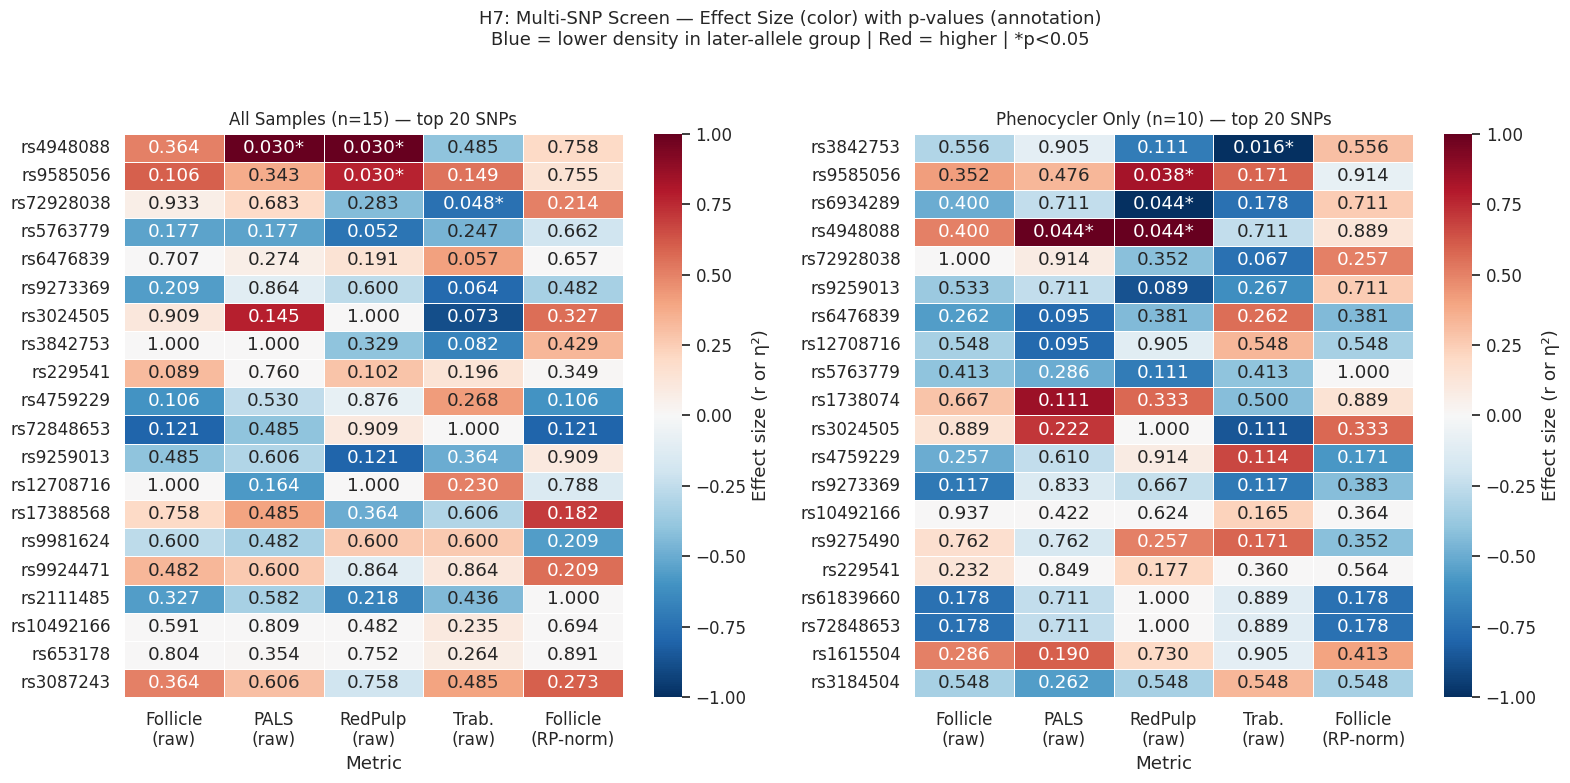

In [10]:
# --- Side-by-side heatmaps: Effect size (color) with p-value annotation ---
# Color = effect size (rank-biserial r for 2 groups, eta² for 3 groups)
# Annotation = raw p-value; bold/starred if p < 0.05
# For 2-group tests: blue = group1 > group2, red = group2 > group1
# For 3-group tests: always positive (eta²), use orange scale

metric_labels = {
    'Follicle_density': 'Follicle\n(raw)',
    'PALS_density': 'PALS\n(raw)',
    'RedPulp_density': 'RedPulp\n(raw)',
    'Trabeculae_density': 'Trab.\n(raw)',
    'Follicle_norm_density': 'Follicle\n(RP-norm)',
}

def make_effect_heatmap(ax, results_df, pivot_p, title, metric_names, metric_labels,
                        max_snps=20):
    """Heatmap with effect size as color, p-value as annotation."""
    # Get top SNPs by min p
    top_snps = pivot_p.sort_values(pivot_p.columns.tolist()).head(max_snps).index

    # Build effect size and p-value matrices
    eff_piv = results_df.pivot_table(index='SNP', columns='Metric', values='Effect_size')
    p_piv = results_df.pivot_table(index='SNP', columns='Metric', values='p_value')
    cols = [c for c in metric_names if c in eff_piv.columns]
    eff_data = eff_piv.loc[[s for s in pivot_p.sort_values('min_p').head(max_snps).index
                            if s in eff_piv.index], cols]
    p_data = p_piv.loc[eff_data.index, cols]

    # Annotation: p-values, starred if significant
    def fmt_p(p):
        if pd.isna(p):
            return ''
        star = '*' if p < 0.05 else ''
        return f'{p:.3f}{star}'
    annot = p_data.map(fmt_p)

    # Diverging colormap: blue (negative r) to white to red (positive r)
    # eta² values (3-group) are always ≥0, so they'll show as white-to-red
    vmax = max(0.5, eff_data.abs().max().max())
    sns.heatmap(
        eff_data, annot=annot, fmt='', cmap='RdBu_r', center=0,
        ax=ax, linewidths=0.5,
        cbar_kws={'label': 'Effect size (r or η²)'},
        xticklabels=[metric_labels.get(m, m) for m in cols],
        vmin=-vmax, vmax=vmax,
    )
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('')

n_snps_show = min(20, len(pivot_all))
fig_h = max(7, n_snps_show * 0.38)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, fig_h))

make_effect_heatmap(ax1, results_all, pivot_all,
                    f'All Samples (n=15) — top {n_snps_show} SNPs',
                    metric_names, metric_labels, n_snps_show)
make_effect_heatmap(ax2, results_pc, pivot_pc,
                    f'Phenocycler Only (n=10) — top {n_snps_show} SNPs',
                    metric_names, metric_labels, n_snps_show)

fig.suptitle('H7: Multi-SNP Screen — Effect Size (color) with p-values (annotation)\n'
             'Blue = lower density in later-allele group | Red = higher | *p<0.05',
             fontsize=13, y=1.03)
fig.tight_layout()
save_figure(fig, 'H7_snp_screen_heatmap')
plt.show()

Top 5 SNPs: ['rs4948088', 'rs9585056', 'rs72928038', 'rs5763779', 'rs6476839']


Saved: analysis/figures/H7_top_snp_boxplots.png


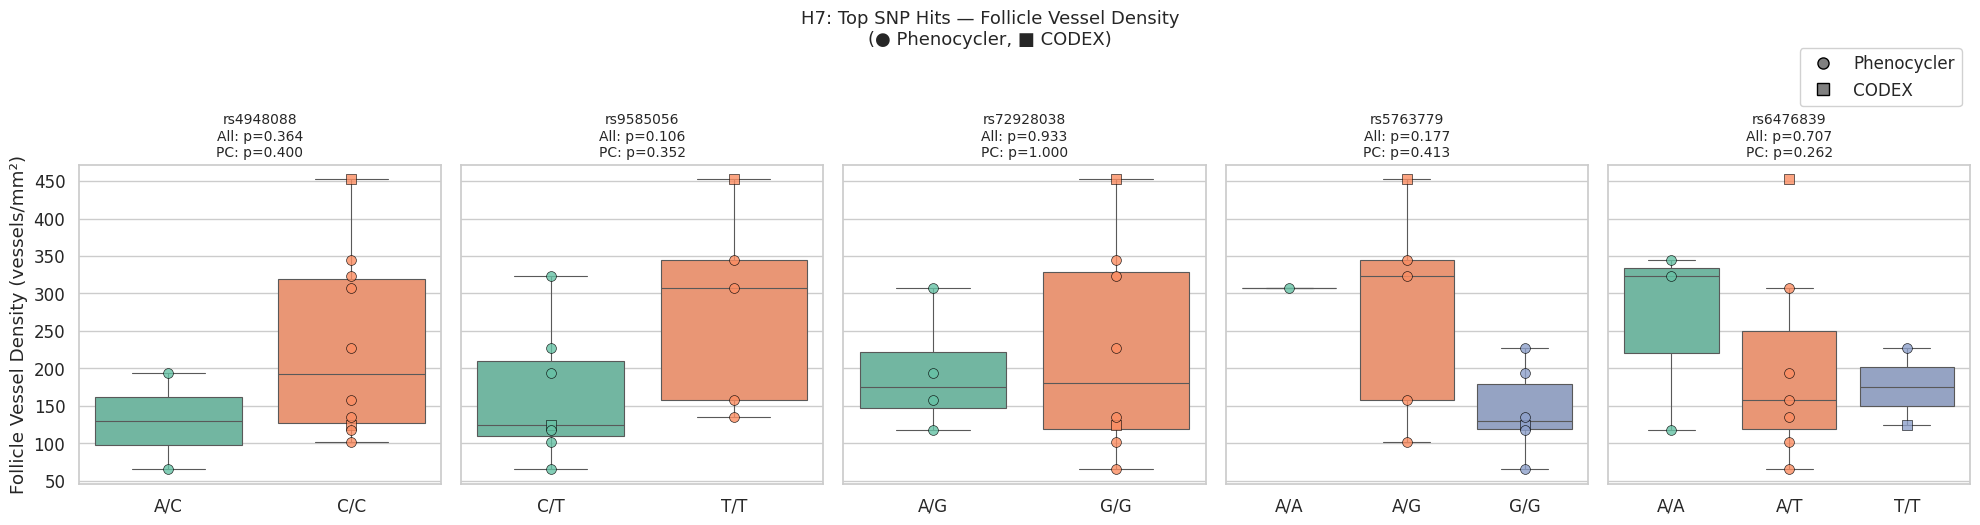

In [11]:
# --- Boxplots for top 5 SNPs (all-sample analysis), colored by platform ---
top5 = pivot_all.head(5).index.tolist()
print(f"Top 5 SNPs: {top5}")

fig, axes = plt.subplots(1, len(top5), figsize=(4 * len(top5), 5), sharey=True)
if len(top5) == 1:
    axes = [axes]

fol_density = metrics_all['Follicle_density']

for ax, snp in zip(axes, top5):
    gmap = snp_geno_maps[snp]
    plot_rows = []
    for sample, geno in gmap.items():
        if sample in fol_density.index:
            plat = 'CODEX' if sample in CODEX_SAMPLES else 'Phenocycler'
            plot_rows.append({'Sample': sample, 'Genotype': geno,
                              'Density': fol_density[sample], 'Platform': plat})
    plot_df = pd.DataFrame(plot_rows)
    geno_order = sorted(plot_df['Genotype'].unique())
    palette = dict(zip(geno_order, sns.color_palette('Set2', len(geno_order))))

    sns.boxplot(data=plot_df, x='Genotype', y='Density', hue='Genotype',
                order=geno_order, hue_order=geno_order, palette=palette,
                ax=ax, linewidth=0.8, fliersize=0, legend=False)
    # Plot points with platform marker
    for _, row in plot_df.iterrows():
        x_pos = geno_order.index(row['Genotype'])
        marker = 's' if row['Platform'] == 'CODEX' else 'o'
        ax.scatter(x_pos, row['Density'], marker=marker, s=50, alpha=0.8,
                   color=palette[row['Genotype']], edgecolors='black', linewidths=0.5,
                   zorder=5)

    # p-values from both cohorts
    p_all = results_all[(results_all['SNP'] == snp) &
                        (results_all['Metric'] == 'Follicle_density')]['p_value']
    p_pc = results_pc[(results_pc['SNP'] == snp) &
                      (results_pc['Metric'] == 'Follicle_density')]['p_value']
    p_all_val = p_all.values[0] if len(p_all) else np.nan
    p_pc_val = p_pc.values[0] if len(p_pc) else np.nan
    title_str = f'{snp}\nAll: p={p_all_val:.3f}'
    if not np.isnan(p_pc_val):
        title_str += f'\nPC: p={p_pc_val:.3f}'
    ax.set_title(title_str, fontsize=10)
    ax.set_xlabel('')
    if ax == axes[0]:
        ax.set_ylabel('Follicle Vessel Density (vessels/mm\u00b2)')
    else:
        ax.set_ylabel('')

# Legend for platform markers
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='gray', markeredgecolor='black',
           markersize=8, label='Phenocycler', linestyle='None'),
    Line2D([0], [0], marker='s', color='gray', markeredgecolor='black',
           markersize=8, label='CODEX', linestyle='None'),
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.99, 0.99),
           framealpha=0.9)

fig.suptitle('H7: Top SNP Hits \u2014 Follicle Vessel Density\n'
             '(\u25cf Phenocycler, \u25a0 CODEX)', fontsize=13, y=1.05)
fig.tight_layout()
save_figure(fig, 'H7_top_snp_boxplots')
plt.show()

In [12]:
# --- Platform effect diagnostic ---
# Compare CODEX vs Phenocycler across metrics (ignoring genotype)
print("Platform comparison (CODEX vs Phenocycler, ignoring genotype):")
print(f"{'Metric':<25} {'CODEX median':>14} {'PC median':>12} {'MW p':>8}")
print('-' * 62)
for metric_name in metric_names:
    m_all = metrics_all[metric_name]
    codex_vals = m_all[[s for s in m_all.index if s in CODEX_SAMPLES]].dropna()
    pc_vals = m_all[[s for s in m_all.index if s in PHENOCYCLER_SAMPLES]].dropna()
    if len(codex_vals) >= 2 and len(pc_vals) >= 2:
        _, p = mannwhitneyu(codex_vals, pc_vals, alternative='two-sided')
        print(f"{metric_name:<25} {codex_vals.median():>14.1f} {pc_vals.median():>12.1f} {p:>8.3f}")
    else:
        print(f"{metric_name:<25} {'n/a':>14} {'n/a':>12}")

Platform comparison (CODEX vs Phenocycler, ignoring genotype):
Metric                      CODEX median    PC median     MW p
--------------------------------------------------------------
Follicle_density                   354.7        175.7    0.055
PALS_density                       289.1        266.4    0.859
RedPulp_density                    374.1        364.5    0.859
Trabeculae_density                 157.4        270.7    0.768
Follicle_norm_density                1.0          0.5    0.019


In [13]:
# --- Validation & Summary ---
rs_all = results_all[results_all['SNP'] == 'rs3184504']
rs_pc = results_pc[results_pc['SNP'] == 'rs3184504']
print("rs3184504 validation:")
print("  All samples:")
if len(rs_all):
    for _, r in rs_all.iterrows():
        print(f"    {r['Metric']}: p={r['p_value']:.4f} ({r['Group_sizes']})")
print("  Phenocycler-only:")
if len(rs_pc):
    for _, r in rs_pc.iterrows():
        print(f"    {r['Metric']}: p={r['p_value']:.4f} ({r['Group_sizes']})")

print(f"\n--- Screen Summary ---")
print(f"All samples: {results_all['SNP'].nunique()} SNPs, {len(results_all)} tests, "
      f"min p={results_all['p_value'].min():.4f}")
print(f"Phenocycler: {results_pc['SNP'].nunique()} SNPs, {len(results_pc)} tests", end='')
if len(results_pc):
    print(f", min p={results_pc['p_value'].min():.4f}")
else:
    print()
print(f"FDR q<0.05 (all): {(results_all['q_value'] < 0.05).sum()} | "
      f"FDR q<0.05 (PC): {(results_pc['q_value'] < 0.05).sum() if len(results_pc) else 0}")

rs3184504 validation:
  All samples:
    Follicle_density: p=0.6809 (C/C:4, C/T:8, T/T:3)
    PALS_density: p=0.4997 (C/C:4, C/T:8, T/T:3)
    RedPulp_density: p=0.6317 (C/C:4, C/T:8, T/T:3)
    Trabeculae_density: p=0.2877 (C/C:4, C/T:8, T/T:3)
    Follicle_norm_density: p=0.8770 (C/C:4, C/T:8, T/T:3)
  Phenocycler-only:
    Follicle_density: p=0.5476 (C/C:3, C/T:6)
    PALS_density: p=0.2619 (C/C:3, C/T:6)
    RedPulp_density: p=0.5476 (C/C:3, C/T:6)
    Trabeculae_density: p=0.5476 (C/C:3, C/T:6)
    Follicle_norm_density: p=0.5476 (C/C:3, C/T:6)

--- Screen Summary ---
All samples: 39 SNPs, 195 tests, min p=0.0303
Phenocycler: 37 SNPs, 185 tests, min p=0.0159
FDR q<0.05 (all): 0 | FDR q<0.05 (PC): 0
